# GWP1: Crude Oil Price Forecasting with Probabilistic Graphical Models

**MScFE 660 Risk Management · Group Work Project 1 · Seungeun Park**

Monthly panel: WTI (target), Brent, U.S. dollar index, VIX, U.S. crude inventories, and the geopolitical risk (GPR) index. Core sample 2006-02 to 2025-12, 239 observations.

The individual cleaning and plotting tasks of Students B and C (bad-data checks, missing-value treatment, time-series plots, multivariate plots) are prepared in their own notebooks and are not repeated here.

### 0. Setup and data loading

Data files live in the team repository. The loader reads from the local `data/` folder when present and otherwise falls back to the repository's raw URL, pinned to a fixed commit so the numbers stay reproducible.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.autolayout": True, "axes.grid": True,
                     "grid.alpha": .3, "font.size": 11})
os.makedirs("figures", exist_ok=True)

REPO_RAW = ("https://raw.githubusercontent.com/fosh-pse/"
            "CPF_Final-Project_Seungeun-Park/"
            "37b7f33174ee41e593194ef47b03997a4be4bba1/GWP1_StudentA/data")

def load_csv(name, **kwargs):
    path = os.path.join("data", name)
    source = path if os.path.exists(path) else f"{REPO_RAW}/{name}"
    return pd.read_csv(source, **kwargs)

panel = load_csv("gwp1_augmented_panel_model_with_gpr.csv",
                 parse_dates=["Date"]).set_index("Date")
print(panel.shape, "| sample:", panel.index.min().date(), "->", panel.index.max().date())
panel.head(3)

(239, 19) | sample: 2006-02-28 -> 2025-12-31


,Month,WTI,Brent,DollarIndex,VIX,CrudeStocks,WTI_ret,Brent_ret,DollarIndex_ret,VIX_change,Inventory_change,Brent_WTI_spread,Spread_change,WTI_lag1,Rolling_vol_6m,GPR,GPR_change,MonthNum,MonthName
Date,,,,,,,,,,,,,,,,,,,
2006-02-28,2006-02,61.63,60.21,100.2112,12.34,309132.75,-0.060749,-0.045138,0.002110,-0.61,5167.75,-1.42,1.08,0.097435,0.063451,95.858192,1.348175,2,Feb
2006-03-31,2006-03,62.69,62.06,100.4281,11.39,323092.80,0.017053,0.030263,0.002162,-0.95,13960.05,-0.63,0.79,-0.060749,0.063977,92.797623,-3.060570,3,Mar
2006-04-30,2006-04,69.44,70.26,99.7435,11.59,329308.25,0.102261,0.124101,-0.006840,0.20,6215.45,0.82,1.45,0.017053,0.072888,89.015800,-3.781822,4,Apr


### 1. Step 3: Macroeconomic and geopolitical variables

The two series below are Student A's responsibility. The rest of the panel (Brent as benchmark, VIX, inventories) is loaded with the group data so that the later steps can run on the full set.

The broad U.S. dollar index comes from FRED (`TWEXBGSMTH`). Oil is priced in dollars, so a stronger dollar tends to weigh on the barrel. The index starts in January 2006, which is what fixes the start of the core sample.

The geopolitical risk index of Caldara and Iacoviello counts news coverage of war, terror and sanctions. It is available from 1985. The series does not trend; it jumps on events and then decays.

dollar raw: 2006-01-01 -> 2026-06-01
GPR raw:    1985-01-31 -> 2026-06-30


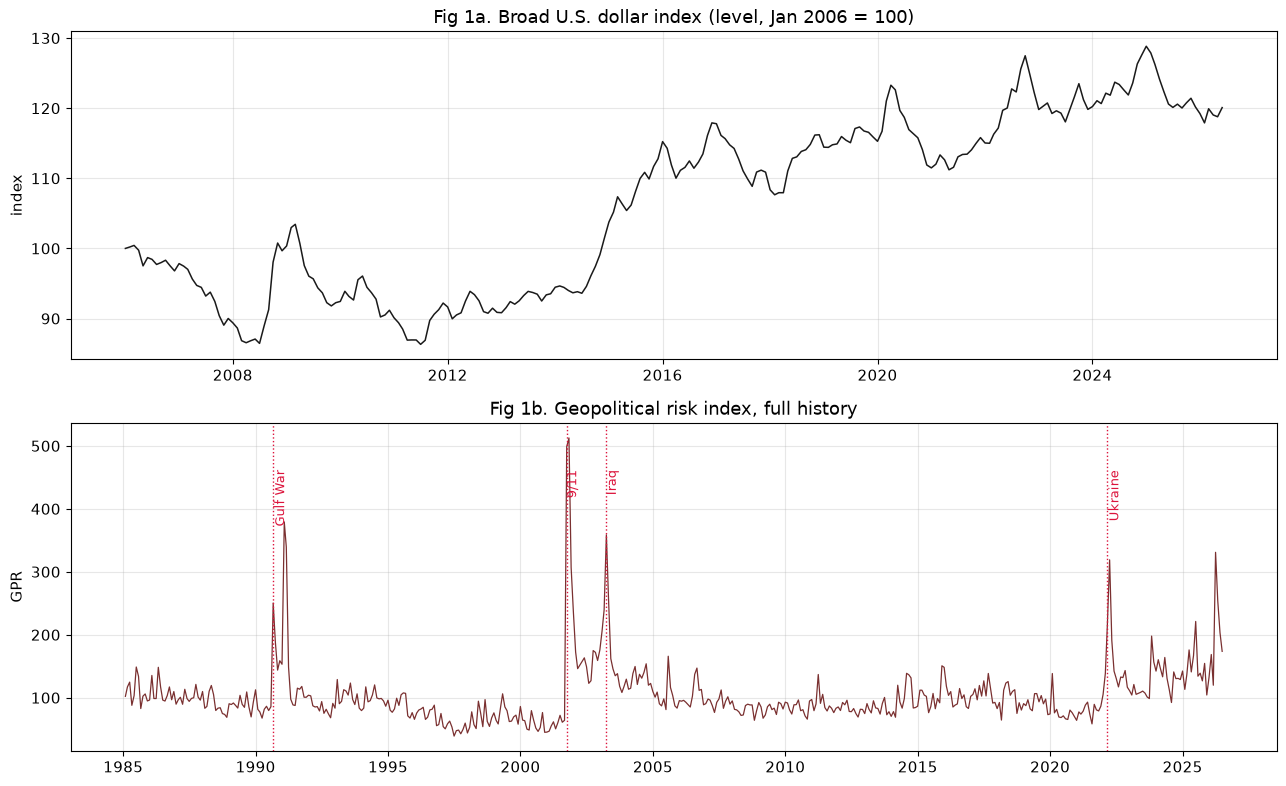

In [2]:
usd_raw = load_csv("TWEXBGSMTH_monthly.csv", parse_dates=["Date"]).set_index("Date")
gpr_raw = load_csv("GPR_monthly.csv", parse_dates=["Date"]).set_index("Date")
print("dollar raw:", usd_raw.index.min().date(), "->", usd_raw.index.max().date())
print("GPR raw:   ", gpr_raw.index.min().date(), "->", gpr_raw.index.max().date())

fig, ax = plt.subplots(2, 1, figsize=(13, 8))
ax[0].plot(usd_raw.index, usd_raw["DollarIndex"], color="#1a1a1a", lw=1.1)
ax[0].set(title="Fig 1a. Broad U.S. dollar index (level, Jan 2006 = 100)", ylabel="index")
ax[1].plot(gpr_raw.index, gpr_raw["GPR"], color="#7a3030", lw=.9)
for d, lab in [("1990-08-31", "Gulf War"), ("2001-09-30", "9/11"),
               ("2003-03-31", "Iraq"), ("2022-02-28", "Ukraine")]:
    ax[1].axvline(pd.Timestamp(d), color="crimson", ls=":", lw=1)
    ax[1].text(pd.Timestamp(d), gpr_raw["GPR"].max()*.9, lab, rotation=90,
               color="crimson", fontsize=9, va="top")
ax[1].set(title="Fig 1b. Geopolitical risk index, full history", ylabel="GPR")
plt.savefig("figures/fig1_levels.png", dpi=130); plt.show()

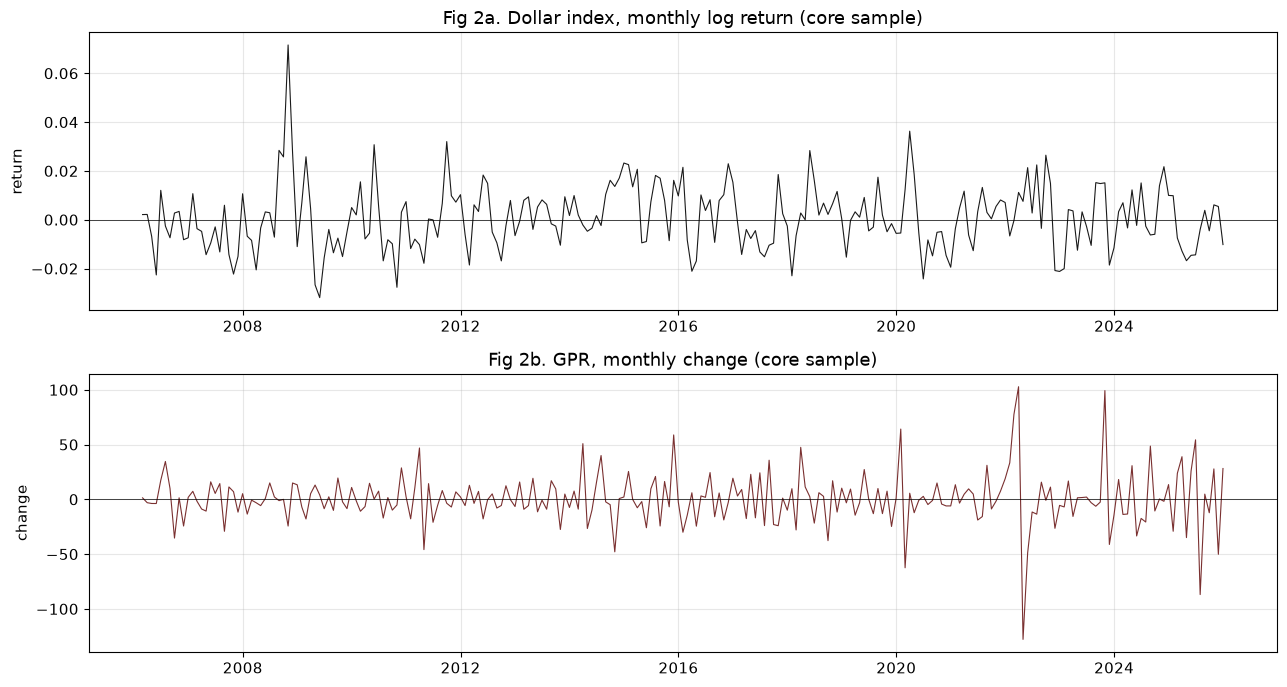

corr(WTI return, dollar return): -0.444


In [3]:
fig, ax = plt.subplots(2, 1, figsize=(13, 7))
ax[0].plot(panel.index, panel["DollarIndex_ret"], color="#1a1a1a", lw=.8)
ax[0].axhline(0, color="k", lw=.5)
ax[0].set(title="Fig 2a. Dollar index, monthly log return (core sample)", ylabel="return")
ax[1].plot(panel.index, panel["GPR_change"], color="#7a3030", lw=.8)
ax[1].axhline(0, color="k", lw=.5)
ax[1].set(title="Fig 2b. GPR, monthly change (core sample)", ylabel="change")
plt.savefig("figures/fig2_changes.png", dpi=130); plt.show()

print("corr(WTI return, dollar return):", round(panel["WTI_ret"].corr(panel["DollarIndex_ret"]), 3))

### 2. Step 4: Data dictionary (group table)

In [4]:
dictionary = pd.DataFrame([
 ["WTI spot price", "Target", "Monthly", "USD/bbl", "Level and log return",
  "EIA-based oil price file", "1986-01", "2026-06", "2006-02", "2025-12"],
 ["Brent spot price", "Benchmark", "Monthly", "USD/bbl", "Level and log return",
  "EIA-based oil price file", "1987-05", "2026-06", "2006-02", "2025-12"],
 ["U.S. dollar index", "Macroeconomic", "Monthly", "Index (2006-01=100)", "Log return",
  "FRED TWEXBGSMTH", "2006-01", "2026-06", "2006-02", "2025-12"],
 ["VIX", "Financial", "Monthly", "Index", "Monthly change",
  "CBOE monthly file", "1990-01", "2026-07", "2006-02", "2025-12"],
 ["Crude inventories ex SPR", "Physical", "Weekly to monthly avg", "kbbl", "Monthly change",
  "EIA WCESTUS1", "1982-08", "2026-06", "2006-02", "2025-12"],
 ["GPR index", "Geopolitical", "Monthly", "Index", "Level and monthly change",
  "Caldara-Iacoviello", "1985-01", "2026-06", "2006-02", "2025-12"],
], columns=["Series", "Group", "Frequency", "Unit", "Transformation",
            "Source", "Raw start", "Raw end", "Model start", "Model end"])
dictionary

,Series,Group,Frequency,Unit,Transformation,Source,Raw start,Raw end,Model start,Model end
0,WTI spot price,Target,Monthly,USD/bbl,Level and log return,EIA-based oil price file,1986-01,2026-06,2006-02,2025-12
1,Brent spot price,Benchmark,Monthly,USD/bbl,Level and log return,EIA-based oil price file,1987-05,2026-06,2006-02,2025-12
2,U.S. dollar index,Macroeconomic,Monthly,Index (2006-01=100),Log return,FRED TWEXBGSMTH,2006-01,2026-06,2006-02,2025-12
3,VIX,Financial,Monthly,Index,Monthly change,CBOE monthly file,1990-01,2026-07,2006-02,2025-12
4,Crude inventories ex SPR,Physical,Weekly to monthly avg,kbbl,Monthly change,EIA WCESTUS1,1982-08,2026-06,2006-02,2025-12
5,GPR index,Geopolitical,Monthly,Index,Level and monthly change,Caldara-Iacoviello,1985-01,2026-06,2006-02,2025-12


Observations after 2025-12 exist in the raw files but stay out of the core panel, because recent months can still be revised. The dollar index start date cuts the sample to 2006 onward. That removes older episodes such as the 1990 Gulf War from the model panel, which the group accepted in exchange for the currency variable.

### 3. Step 5: Extreme-outlier screening (Student A, applied to all series)

Each observation gets a robust z-score built from the median and the median absolute deviation. Median-based statistics are not pulled around by the outliers being searched for, which is the weakness of a plain mean-based z-score. A month is flagged when the absolute score is above 5.

Flagged months are reviewed and kept, not deleted. In this market the extreme months are usually real events, and removing them would strip out the stress behaviour a risk model has to learn. The bad-data and missing-value checks are Student B's and Student C's parts of this step.

In [5]:
SERIES = ["WTI_ret", "Brent_ret", "DollarIndex_ret", "VIX_change",
          "Inventory_change", "GPR_change"]

def robust_z(s):
    med = s.median()
    mad = (s - med).abs().median()
    return 0.6745 * (s - med) / mad

flags = []
for c in SERIES:
    z = robust_z(panel[c].dropna())
    for d, v in z[z.abs() > 5].items():
        flags.append([d.strftime("%Y-%m"), c, round(panel.loc[d, c], 4), round(v, 2)])

flag_tab = (pd.DataFrame(flags, columns=["Month", "Series", "Value", "Robust z"])
              .sort_values(["Series", "Month"]).reset_index(drop=True))
flag_tab.to_csv("outlier_flags.csv", index=False)
print(len(flag_tab), "flagged observations")
flag_tab

15 flagged observations


,Month,Series,Value,Robust z
0,2020-03,Brent_ret,-0.5532,-6.68
1,2020-04,Brent_ret,-0.5548,-6.70
2,2020-05,Brent_ret,0.4691,5.42
3,2008-10,DollarIndex_ret,0.0716,5.92
4,2022-03,GPR_change,102.7959,6.57
5,2022-04,GPR_change,-127.8118,-8.06
6,2023-10,GPR_change,99.2522,6.35
7,2025-07,GPR_change,-86.9129,-5.47
8,2008-09,VIX_change,18.7400,5.28
9,2008-10,VIX_change,20.5000,5.77


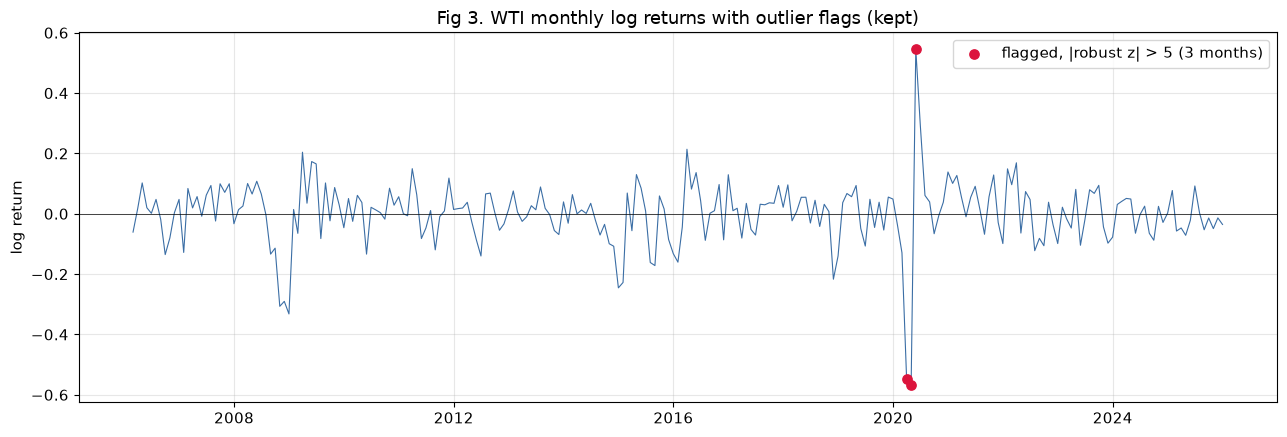

In [6]:
r = panel["WTI_ret"]
z = robust_z(r)
ext = r[z.abs() > 5]
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(r.index, r, color="#3b6ea5", lw=.8)
ax.scatter(ext.index, ext, color="crimson", zorder=5, s=45,
           label=f"flagged, |robust z| > 5 ({len(ext)} months)")
ax.axhline(0, color="k", lw=.5)
ax.set(title="Fig 3. WTI monthly log returns with outlier flags (kept)", ylabel="log return")
ax.legend()
plt.savefig("figures/fig3_flags.png", dpi=130); plt.show()

### 4. Step 6: The sterilized panel

The model panel combines the three cleaning passes. Rows are dropped only when a transformation leaves a variable undefined: the first month of each return series, the first six months of the rolling volatility, and everything before 2006-02 where the dollar index does not exist. The checks below confirm the panel is complete, has no impossible values and no duplicated dates. The flagged stress months from Step 5 stay in.

In [7]:
wti_raw = load_csv("wti-monthly.csv", parse_dates=["Date"]).set_index("Date")
print("raw WTI months:", len(wti_raw), "| model panel months:", len(panel))
print("missing values in model panel:", int(panel[SERIES].isna().sum().sum()))
print("non-positive prices:", int((panel[["WTI", "Brent"]] <= 0).sum().sum()))
print("duplicated dates:", int(panel.index.duplicated().sum()))

raw WTI months: 486 | model panel months: 239
missing values in model panel: 0
non-positive prices: 0
duplicated dates: 0


### 5. Step 7: Distributional plots (Student A, all datasets)

One histogram per transformed series, each against its own Normal fit, then a closer look at the target. Time-series plots (Student B) and multivariate plots (Student C) are in their notebooks.

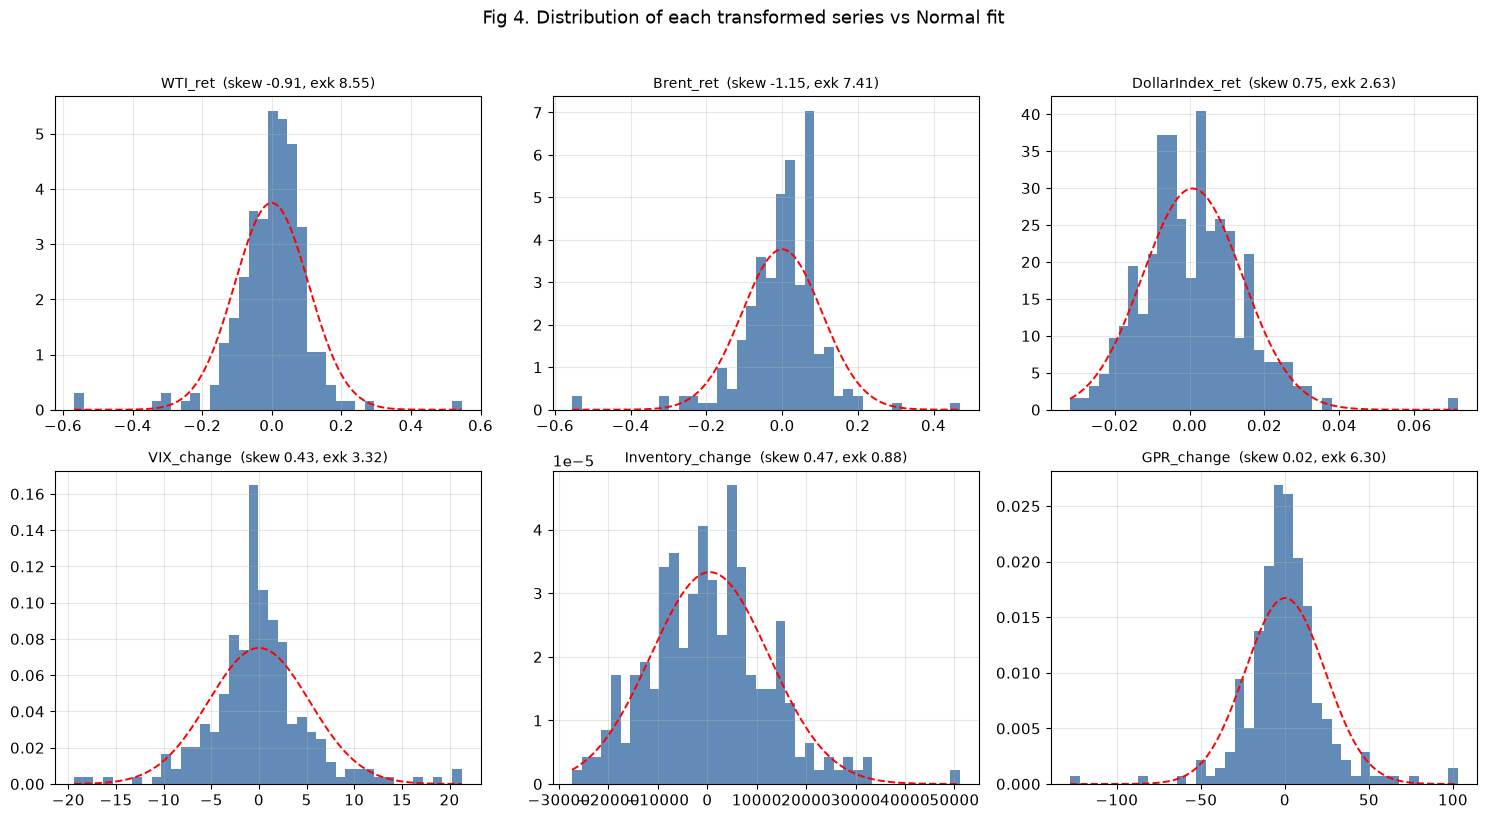

,mean,std,skew,excess kurtosis,min,max
WTI_ret,-0.0005,0.1065,-0.9073,8.5528,-0.5681,0.5456
Brent_ret,-0.0000,0.1056,-1.1488,7.4128,-0.5548,0.4691
DollarIndex_ret,0.0008,0.0133,0.7456,2.6345,-0.0319,0.0716
VIX_change,0.0084,5.3159,0.4258,3.3223,-19.3900,21.2700
Inventory_change,504.1402,11969.0254,0.4669,0.8834,-27361.7500,51046.5000
GPR_change,0.1589,23.8567,0.0156,6.3015,-127.8118,102.7959


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), SERIES):
    s = panel[c].dropna()
    ax.hist(s, bins=40, density=True, color="#3b6ea5", alpha=.8)
    x = np.linspace(s.min(), s.max(), 300)
    ax.plot(x, stats.norm.pdf(x, s.mean(), s.std()), "r--", lw=1.4)
    ax.set_title(f"{c}  (skew {s.skew():.2f}, exk {s.kurt():.2f})", fontsize=10)
fig.suptitle("Fig 4. Distribution of each transformed series vs Normal fit", y=1.02)
plt.savefig("figures/fig4_grid.png", dpi=130, bbox_inches="tight"); plt.show()

summary = pd.DataFrame({c: {"mean": panel[c].mean(), "std": panel[c].std(),
                            "skew": panel[c].skew(), "excess kurtosis": panel[c].kurt(),
                            "min": panel[c].min(), "max": panel[c].max()}
                        for c in SERIES}).T.round(4)
summary.to_csv("distribution_summary.csv")
summary

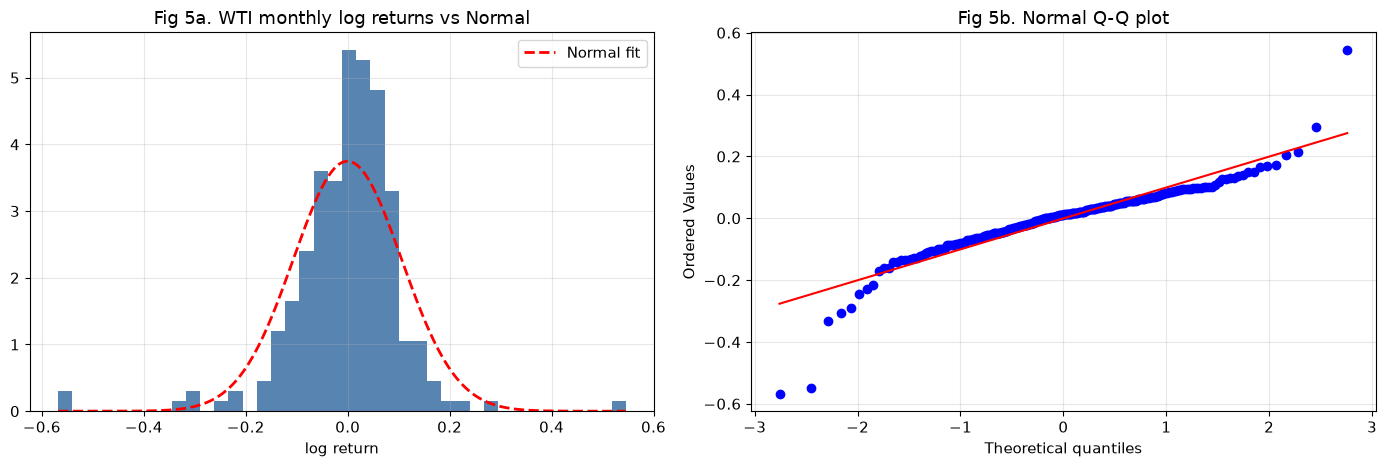

WTI: skew -0.91, excess kurtosis 8.55


In [9]:
r = panel["WTI_ret"].dropna()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].hist(r, bins=40, density=True, color="#3b6ea5", alpha=.85)
x = np.linspace(r.min(), r.max(), 400)
ax[0].plot(x, stats.norm.pdf(x, r.mean(), r.std()), "r--", lw=2, label="Normal fit")
ax[0].set(title="Fig 5a. WTI monthly log returns vs Normal", xlabel="log return")
ax[0].legend()
stats.probplot(r, dist="norm", plot=ax[1])
ax[1].set_title("Fig 5b. Normal Q-Q plot")
plt.savefig("figures/fig5_wti.png", dpi=130); plt.show()
print(f"WTI: skew {r.skew():.2f}, excess kurtosis {r.kurt():.2f}")

### 6. Step 8: Group questions

     return acf  squared-return acf
lag                                
1         0.289               0.712
2        -0.034               0.374
3        -0.120               0.067
4        -0.110              -0.027
5        -0.035              -0.027
6        -0.032              -0.030


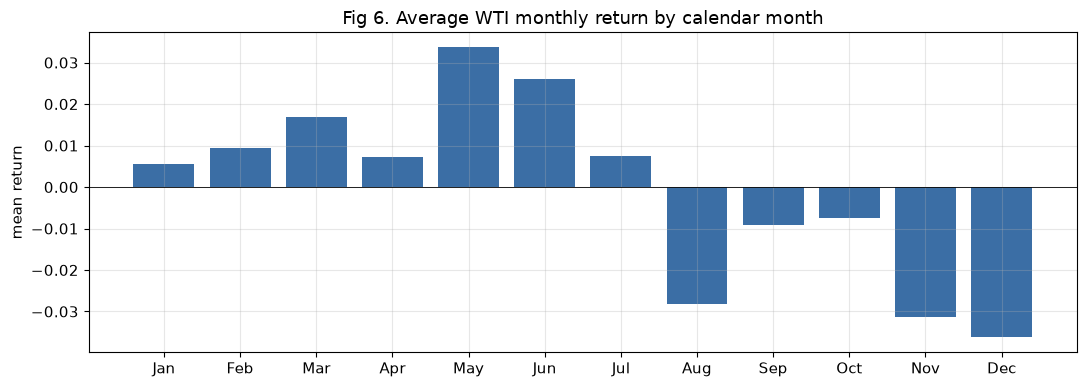

                  WTI_ret  Brent_ret  DollarIndex_ret  VIX_change  \
WTI_ret              1.00       0.96            -0.44       -0.12   
Brent_ret            0.96       1.00            -0.45       -0.13   
DollarIndex_ret     -0.44      -0.45             1.00        0.23   
VIX_change          -0.12      -0.13             0.23        1.00   
Inventory_change    -0.18      -0.15             0.11       -0.13   
GPR_change           0.07       0.09            -0.02       -0.07   

                  Inventory_change  GPR_change  
WTI_ret                      -0.18        0.07  
Brent_ret                    -0.15        0.09  
DollarIndex_ret               0.11       -0.02  
VIX_change                   -0.13       -0.07  
Inventory_change              1.00       -0.08  
GPR_change                   -0.08        1.00  


In [10]:
# supporting numbers: autocorrelation, seasonality, plain correlations
acf = pd.DataFrame({
    "return acf": [r.autocorr(k) for k in range(1, 7)],
    "squared-return acf": [(r**2).autocorr(k) for k in range(1, 7)],
}, index=pd.Index(range(1, 7), name="lag")).round(3)
print(acf)

season = (panel.assign(m=panel.index.month)
               .groupby("m")["WTI_ret"].agg(["mean", lambda s: s.abs().mean()]))
season.columns = ["mean return", "mean abs return"]
season.index = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(season.index, season["mean return"], color="#3b6ea5")
ax.axhline(0, color="k", lw=.6)
ax.set(title="Fig 6. Average WTI monthly return by calendar month", ylabel="mean return")
plt.savefig("figures/fig6_seasonality.png", dpi=130); plt.show()

corr = panel[SERIES].corr().round(2)
print(corr)

**(a) What makes oil prices look different from other asset prices?** The return series is dominated by event months. The 2008 crisis, the 2014-15 supply glut and the 2020 pandemic all show up as jumps of 25 to 57 percent in a single month, and turbulent months arrive in clusters rather than alone. Oil also has a physical side that equities do not: storage and inventories link the price to real barrels. The calendar-month averages in Fig 6 move around (stronger springs, weaker late years in this sample), though the pattern is not stable enough to build on by itself.

**(b) What types of distributions do oil returns have?** Fat-tailed and left-skewed. WTI monthly log returns have skewness near -0.9 and excess kurtosis near 8.6, against 0 for a Normal distribution. The histogram is more peaked than the Normal fit and the Q-Q plot bends away from the line at both ends. A Normal assumption would understate the chance of large losses.

**(c) What type of autocorrelation do the oil returns have?** Returns themselves show some positive autocorrelation at lag 1 (about 0.29) and little after that. Squared returns are a different story: 0.71 at lag 1 and 0.37 at lag 2. Size is persistent even where direction is not, which is volatility clustering.

**(d) What other stylized facts can be stated?** WTI and Brent move almost one for one in the same month (correlation 0.96), so the benchmark carries description rather than forecasting value. The dollar is inversely related to oil (about -0.44). Stress variables skew the opposite way from oil: the dollar, the VIX and GPR all jump upward in the months when oil crashes. Finally, the extreme months found in Step 5 account for most of the tail mass, so any model for this panel has to survive them.

### 7. Step 9: Probabilistic graphical models (Student A)

A probabilistic graphical model represents a joint probability distribution with a graph. Nodes are random variables and edges are direct dependencies. A missing edge states a conditional independence, and that is what makes the model workable: the joint distribution over the panel's variables is far too large to estimate from 239 observations, but the graph breaks it into small local pieces that can be estimated one at a time. The assumptions also sit in the open, where the group can question them.

A belief network, also called a Bayesian network, uses a directed acyclic graph. Each node holds a conditional probability table given its parents, and the joint distribution is the product of those tables. Direction lets the graph state one-way claims, for example that a geopolitical shock raises the probability of an extreme oil month. It also supports evidence updating: fix what is observed and read off the conditional distribution of the target. That matches the question this project asks about the WTI return state.

A Markov network uses an undirected graph. Edges stand for symmetric association, the joint distribution factorises over cliques through potential functions, and a normalising constant is needed. It suits problems where dependence has no natural direction, such as spatial data, but it cannot say which way an influence runs.

The group therefore works with a belief network. The undirected view still appears inside the procedure, since structure learning first builds an undirected skeleton from independence tests and only then orients the edges. Summaries of parameter versus structure learning (Student B) and of Markov chains and blankets (Student C) are in their sections.

### 8. Step 10: Inferred-causality pseudocode (group)

```
Input : cleaned monthly panel D, target Y = WTI_return_state,
        conditional-independence test CI(a, b | S)
Output: candidate directed acyclic graph G

1. Start from the complete undirected graph over the panel variables.
2. For each adjacent pair (a, b), search for a conditioning set S such that
   CI(a, b | S) holds. If one is found, remove the edge a - b and record S
   as the separating set of (a, b).
3. For each triple a - c - b where a and b are not adjacent:
   if c is not in the separating set of (a, b), orient a -> c <- b.
4. Propagate orientations: do not create directed cycles and do not create
   new colliders that step 3 did not identify.
5. Apply timing restrictions: lagged variables may point at Y; Y may not
   point back at variables observed earlier.
6. Return G and estimate the conditional probability tables on it.
```

The output is a candidate structure for GWP2. An edge recovered this way is a hypothesis consistent with the independence pattern in the data, not proof of economic causation.

---
Outputs written by this notebook: `outlier_flags.csv`, `distribution_summary.csv` and the six figures under `figures/`. Re-running the notebook from the top reproduces all of them.